In [ ]:
# 쓰레기 재활용 분류기 모델 + 전이학습 + 미세 조정
# google drive에 저장된 waste dataset는 읽어서 처리

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, classification_report

DATASET_PATH = '/content/drive/MyDrive/Garbage_classification'

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH, validation_split=0.2,
    subset='training',
    seed=SEED, image_size=IMG_SIZE, batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH, validation_split=0.2,
    subset='validation',
    seed=SEED, image_size=IMG_SIZE, batch_size=BATCH_SIZE
)

print(train_ds.element_spec, ' ', len(val_ds.element_spec))
print(val_ds.element_spec, ' ', len(val_ds.element_spec))

class_names = train_ds.class_names
print('class_name : ', class_names)

Found 2527 files belonging to 6 classes.
Using 2022 files for training.
Found 2527 files belonging to 6 classes.
Using 505 files for validation.
(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))   2
(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))   2
class_name :  ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [ ]:
# 원래 validation dataset을 다시 validation + test datset으로 나누기
# train / validation / test 3rofh sksnrl (8 :1 :1)
val_batchs = tf.data.experimental.cardinality(val_ds) # cardinality : batch 갯수 세기(batch 기준)
test_ds = val_ds.take(val_batchs // 2)
val_ds = val_ds.skip(val_batchs // 2)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

# 데이터 증강
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),  # 좌우 반전
    layers.RandomRotation(0.1),       # 이미지 회전
    layers.RandomZoom(0.1),           # 이미지 확대/축소
    layers.RandomContrast(0.1)        # 명암 변화
])

base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    data_augmentation,    # 갯수를 늘린 것이 아니라 학습 시 이미지가 입력될 때 랜덤하게 변형이 됨
    layers.Rescaling(1./127.5, offset=-1),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(units=128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(units=len(class_names), activation='softmax')
])

print(model.summary())

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

None


In [ ]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(factor=0.3, patience=2, verbose=1)
    # 학습률이 고정되면 경우에 따라 학습이 발산 또는 너무 작아져 학습이 느려질 수 있다.
]

history_baseline = model.fit(
    train_ds, validation_data=val_ds, epochs=100, callbacks=callbacks
)

baseline_loss, baseline_acc = model.evaluate(test_ds)
print(f"fine tuning : loss:{baseline_loss: .4f}, acc:{baseline_acc: .4f}")

Epoch 1/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 782s 12s/step - accuracy: 0.6048 - loss: 1.0859 - val_accuracy: 0.7671 - val_loss: 0.6416 - learning_rate: 0.0010
Epoch 2/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 9s 143ms/step - accuracy: 0.7493 - loss: 0.6971 - val_accuracy: 0.8193 - val_loss: 0.5189 - learning_rate: 0.0010
Epoch 3/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 9s 138ms/step - accuracy: 0.7770 - loss: 0.5886 - val_accuracy: 0.8514 - val_loss: 0.5220 - learning_rate: 0.0010
Epoch 4/100
63/64 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.8062 - loss: 0.5321
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 155ms/step - accuracy: 0.8131 - loss: 0.5218 - val_accuracy: 0.7992 - val_loss: 0.6015 - learning_rate: 0.0010
Epoch 5/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 9s 138ms/step - accuracy: 0.8225 - loss: 0.4655 - val_accuracy: 0.8635 - val_loss: 0.4503 - learning_rate: 3.0000e-04
Epoch 6/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 11s 148ms/step - accuracy: 0.8378 - loss

In [ ]:
# Fine Tunning
base_model.trainable = True # backbone unfreeze

for layer in base_model.layers[:-30]:
  layer.trainable = False

# fine tunning compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_finetune = model.fit(
    train_ds, validation_data=val_ds, epochs=100, callbacks=callbacks
)

finetune_loss, finetune_acc = model.evaluate(test_ds)
print(f"fine tuning : loss:{finetune_loss: .4f}, acc:{finetune_acc: .4f}")

model.save('garbage_classify.keras')

Epoch 1/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 25s 186ms/step - accuracy: 0.7626 - loss: 0.6227 - val_accuracy: 0.8795 - val_loss: 0.4131 - learning_rate: 1.0000e-05
Epoch 2/100
63/64 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.7938 - loss: 0.5715
Epoch 2: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 154ms/step - accuracy: 0.7908 - loss: 0.5732 - val_accuracy: 0.8675 - val_loss: 0.5009 - learning_rate: 1.0000e-05
Epoch 3/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 11s 175ms/step - accuracy: 0.8086 - loss: 0.5262 - val_accuracy: 0.8956 - val_loss: 0.4064 - learning_rate: 3.0000e-06
Epoch 4/100
63/64 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.7988 - loss: 0.5223
Epoch 4: ReduceLROnPlateau reducing learning rate to 8.999999636216671e-07.
64/64 ━━━━━━━━━━━━━━━━━━━━ 11s 172ms/step - accuracy: 0.8150 - loss: 0.5220 - val_accuracy: 0.8594 - val_loss: 0.4731 - learning_rate: 3.0000e-06
Epoch 5/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 11s 176ms/step - accuracy:

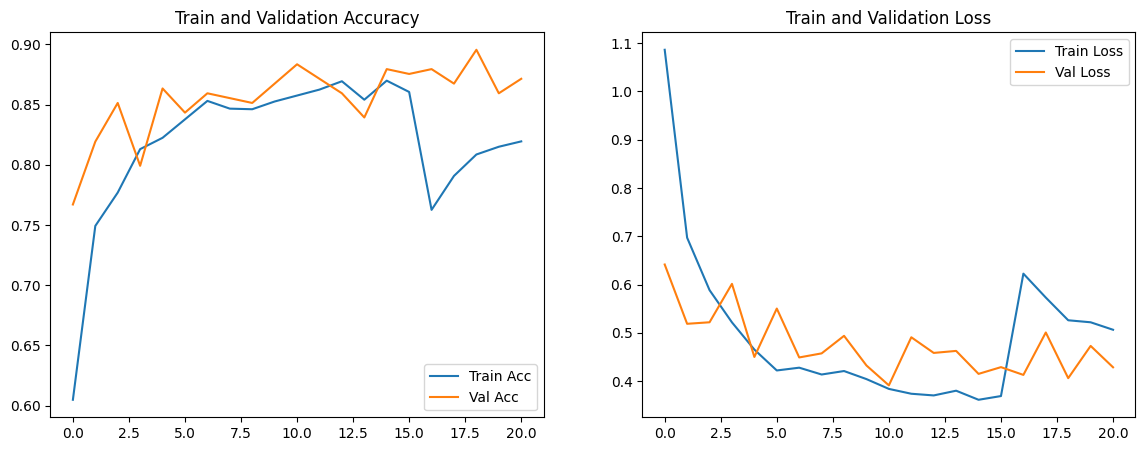

In [ ]:
# 시각화
acc = history_baseline.history['accuracy'] + history_finetune.history['accuracy']
val_acc = history_baseline.history['val_accuracy'] + history_finetune.history['val_accuracy']
loss = history_baseline.history['loss'] + history_finetune.history['loss']
val_loss = history_baseline.history['val_loss'] + history_finetune.history['val_loss']

epoch_range = range(len(acc))
plt.figure(figsize=(14, 5))

# acc
plt.subplot(1, 2, 1)
plt.plot(epoch_range, acc, label='Train Acc')
plt.plot(epoch_range, val_acc, label='Val Acc')
plt.legend(loc='lower right')
plt.title('Train and Validation Accuracy')

# loss
plt.subplot(1, 2, 2)
plt.plot(epoch_range, loss, label='Train Loss')
plt.plot(epoch_range, val_loss, label='Val Loss')
plt.legend(loc='upper right')
plt.title('Train and Validation Loss')

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step


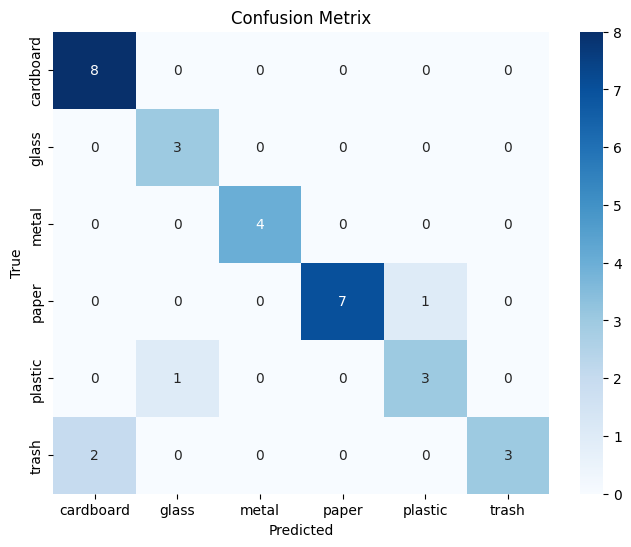

              precision    recall  f1-score   support

   cardboard       0.80      1.00      0.89         8
       glass       0.75      1.00      0.86         3
       metal       1.00      1.00      1.00         4
       paper       1.00      0.88      0.93         8
     plastic       0.75      0.75      0.75         4
       trash       1.00      0.60      0.75         5

    accuracy                           0.88        32
   macro avg       0.88      0.87      0.86        32
weighted avg       0.90      0.88      0.87        32



In [ ]:
# 예측
y_true = []  # Initialize y_true
y_pred = []  # Initialize y_pred explicitly as well

for images, labels in test_ds.take(1):
  predictions = model.predict(images)
  y_true.extend(labels.numpy())
  y_pred.extend(np.argmax(predictions, axis=1))

cm = confusion_matrix(y_true, y_pred)
#  print(cm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Metrix')
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))

In [ ]:
# 새로운 이미지를 분류 예측 - 여기서부터는 새로운 파일이라 가정
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing import image

model = tf.keras.models.load_model('garbage_classify.keras')

class_names = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

def predict_garbageFunc(img_path):
  img = image.load_img(img_path, target_size=(224, 224))
  img_array = image.img_to_array(img)
  img_array = np.expand_dims(img_array, axis=0) # (1, 224, 224, 3)

  predictions = model.predict(img_array)
  pred_index = np.argmax(predictions)
  pred_class = class_names[pred_index]
  confidence = np.argmax(predictions)

  print("예측 결과:", pred_class)
  print("신뢰도: ", round(confidence * 100, 2), '%')
  return pred_class, confidence

predict_garbageFunc('myimage.jpeg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
예측 결과: cardboard
신뢰도:  0 %


('cardboard', np.int64(0))